# Vehicle Detection - YOLOv12 Training
**Capstone Project Module 4 - Purwadhika**

Model ini dilatih untuk mendeteksi 3 kelas kendaraan:
- 🚌 **Bus**
- 🚗 **Car**
- 🚐 **Van**

---
### Alur Pipeline:
1. Setup environment & GPU check
2. Mount Google Drive & load dataset
3. Exploratory Data Analysis (EDA)
4. Training YOLOv12 dengan augmentasi non-geometris
5. Evaluasi model (mAP, Precision, Recall)
6. Simpan model ke Google Drive

## Step 1: Setup Environment

In [1]:
# Install dependencies
!pip install ultralytics supervision -q

You should consider upgrading via the 'c:\users\user\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [2]:
# Cek GPU yang tersedia
!nvidia-smi

Fri May 22 02:27:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050      WDDM  |   00000000:06:00.0  On |                  N/A |
| 41%   34C    P8              9W /   70W |     901MiB /   6144MiB |     28%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.8.0+cu128
True
1
NVIDIA GeForce RTX 3050


In [4]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
from ultralytics import YOLO
import supervision as sv

HOME = os.getcwd()
print(f'Working directory: {HOME}')

Working directory: c:\Users\User\Documents\CAPSTONE4


## Step 2: Load Dataset

In [ ]:
#  SESUAIKAN path ini dengan lokasi dataset kamu 
DATASET_PATH = "vehicle-detection"  # <-- GANTI SESUAI PATH KAMU

# Verifikasi struktur dataset
for split in ['train', 'valid', 'test']:
    img_count = len(list(Path(f"{DATASET_PATH}/{split}/images").glob('*')))
    lbl_count = len(list(Path(f"{DATASET_PATH}/{split}/labels").glob('*')))
    print(f"  {split:6s}: {img_count} images, {lbl_count} labels")

# Baca data.yaml
with open(f"{DATASET_PATH}/data.yaml", 'r') as f:
    data_config = yaml.safe_load(f)
print(f"\nClasses: {data_config['names']}")
print(f"Num classes: {data_config['nc']}")

  train : 9218 images, 9218 labels
  valid : 287 images, 287 labels
  test  : 220 images, 220 labels

Classes: ['bus', 'car', 'van']
Num classes: 3


## Step 3: Exploratory Data Analysis (EDA)

In [2]:
# Hitung distribusi label per split
def count_labels(label_dir, class_names):
    counter = Counter()

    label_dir = Path(label_dir)

    if not label_dir.exists():
        print(f"Folder tidak ditemukan: {label_dir}")
        return counter

    for lbl_file in label_dir.glob("*.txt"):
        try:
            with open(lbl_file, "r", encoding="utf-8") as f:
                for line in f:
                    if line.strip():
                        cls_id = int(line.split()[0])
                        counter[class_names[cls_id]] += 1

        except Exception as e:
            print(f"Skip file rusak: {lbl_file.name}")
            continue

    return counter

class_names = data_config['names']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Label per Split', fontsize=14, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71']
for idx, split in enumerate(['train', 'valid', 'test']):
    counts = count_labels(f"{DATASET_PATH}/{split}/labels", class_names)
    labels = list(counts.keys())
    values = list(counts.values())
    axes[idx].bar(labels, values, color=colors)
    axes[idx].set_title(f'{split.capitalize()} Set')
    axes[idx].set_ylabel('Jumlah Objek')
    for i, v in enumerate(values):
        axes[idx].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDistribusi label berhasil divisualisasikan!")

NameError: name 'data_config' is not defined

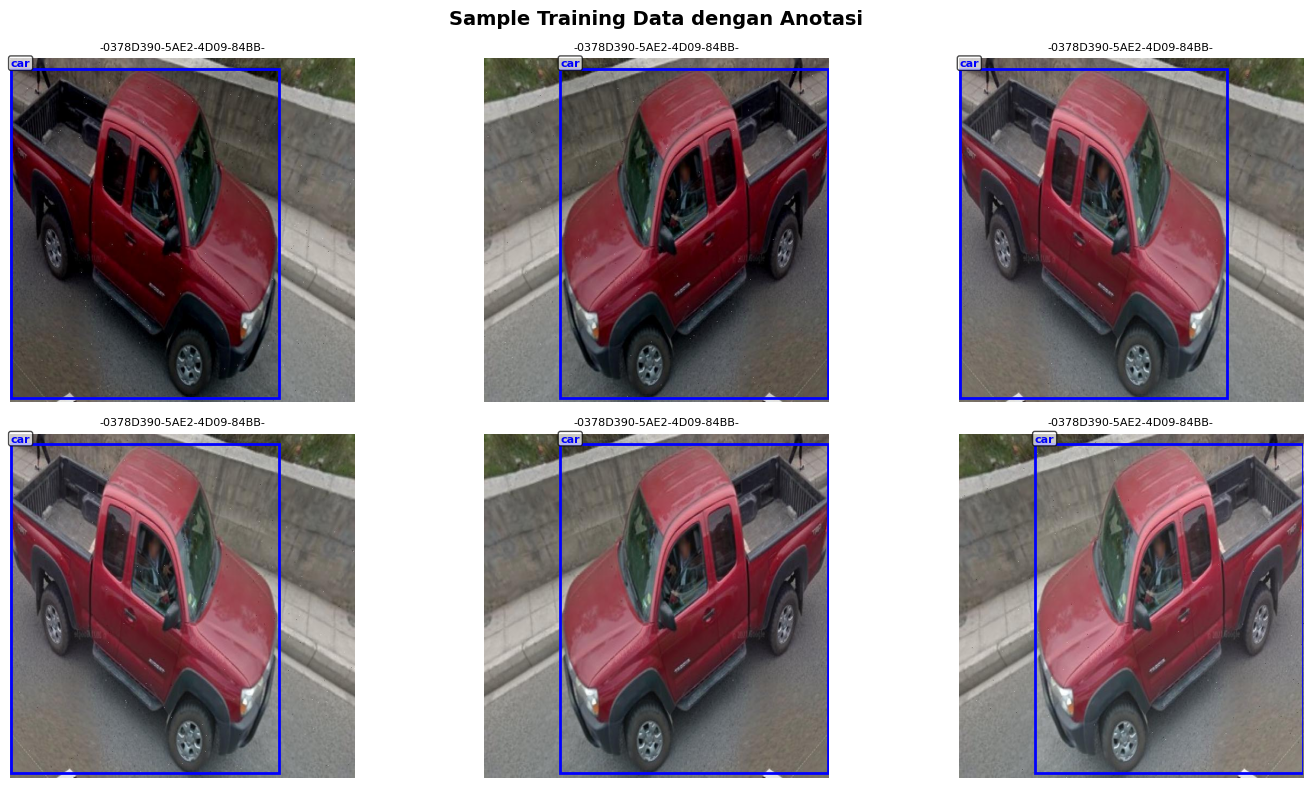

In [ ]:
# Visualisasi sample gambar dari training set dengan bounding box
def yolo_to_pixel(bbox, img_w, img_h):
    """Convert YOLO format (cx, cy, w, h) ke pixel coordinates."""
    cx, cy, w, h = bbox
    x1 = int((cx - w/2) * img_w)
    y1 = int((cy - h/2) * img_h)
    x2 = int((cx + w/2) * img_w)
    y2 = int((cy + h/2) * img_h)
    return x1, y1, x2, y2

train_images = list(Path(f"{DATASET_PATH}/train/images").glob('*'))[:6]
class_colors = {'bus': 'red', 'car': 'blue', 'van': 'green'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sample Training Data dengan Anotasi', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, img_path in enumerate(train_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = Path(f"{DATASET_PATH}/train/labels") / (img_path.stem + '.txt')

    axes[i].imshow(img)
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                bbox = list(map(float, parts[1:5]))
                x1, y1, x2, y2 = yolo_to_pixel(bbox, w, h)
                cls_name = class_names[cls_id]
                color = class_colors.get(cls_name, 'yellow')
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                         linewidth=2, edgecolor=color, facecolor='none')
                axes[i].add_patch(rect)
                axes[i].text(x1, y1-5, cls_name, color=color,
                             fontsize=8, fontweight='bold',
                             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

    axes[i].set_title(img_path.stem[:25], fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_data.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Training YOLOv12

### Strategi Augmentasi
Augmentasi yang digunakan adalah **non-geometris** (tidak mengubah posisi/bentuk objek):
- `hsv_h`, `hsv_s`, `hsv_v` → variasi warna, saturasi, kecerahan
- `erasing` → random erasing untuk simulasi occlusion

Augmentasi yang **dinonaktifkan** (geometris - tidak sesuai guidelines):
- `fliplr`, `flipud`, `degrees`, `translate`, `scale`, `shear`, `perspective`

In [8]:
# Download YOLOv12 via github
!wget -q https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
print("YOLOv12n weights downloaded ✅")

YOLOv12n weights downloaded ✅


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
# Load model
model = YOLO('yolov12n.pt')
print(f"Model loaded: {model.info()}")

YOLOv12n summary: 272 layers, 2,603,056 parameters, 0 gradients, 6.7 GFLOPs
Model loaded: (272, 2603056, 0, 6.6535552)


In [8]:
!pip install pi-heif

  Using cached pi_heif-1.3.0.tar.gz (17.1 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
    Preparing wheel metadata: started
    Preparing wheel metadata: finished with status 'done'
Failed to build pi-heif


  ERROR: Command errored out with exit status 1:
   command: 'c:\users\user\appdata\local\programs\python\python39\python.exe' 'c:\users\user\appdata\local\programs\python\python39\lib\site-packages\pip\_vendor\pep517\in_process\_in_process.py' build_wheel 'C:\Users\User\AppData\Local\Temp\tmpmvrl3ezv'
       cwd: C:\Users\User\AppData\Local\Temp\pip-install-ompqvnls\pi-heif_95901d65097745c2b5ae038e6d90bc17
  Complete output (81 lines):
  C:\Users\User\AppData\Local\Temp\pip-build-env-exm5vsbp\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
  !!
  
          ********************************************************************************
          Please consider removing the following classifiers in favor of a SPDX license expression:
  
          License :: OSI Approved :: GNU Lesser General Public License v3 (LGPLv3)
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for d

In [ ]:
# Training
results = model.train(
    data=f'{DATASET_PATH}/data.yaml',
    epochs=150,
    batch=2,
    imgsz=640,
    exist_ok=True,
    patience=10,             # Early stopping jika tidak ada improvement
    save_period=10,          # Simpan checkpoint setiap 10 epoch
    val=True,
    verbose=True,
    device=0,                # Gunakan GPU
    workers=0,                

    # Augmentasi NON-GEOMETRIS
    hsv_h=0.015,             # Variasi hue
    hsv_s=0.7,               # Variasi saturasi
    hsv_v=0.4,               # Variasi brightness
    erasing=0.4,             # Random erasing (simulasi occlusion)

    # Augmentasi GEOMETRIS dinonaktifkan
    fliplr=0.0,
    flipud=0.0,
    degrees=0.0,
    translate=0.0,
    scale=0.0,
    shear=0.0,
    perspective=0.0,
)

print("\nTraining selesai! ✅")

Ultralytics 8.4.52  Python-3.9.6 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicle-detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

KeyboardInterrupt: 

In [ ]:
# RESUME TRAINING
model = YOLO('runs/detect/train/weights/last.pt')
results = model.train(resume=True)

## Step 5: Evaluasi Model

=== Confusion Matrix ===


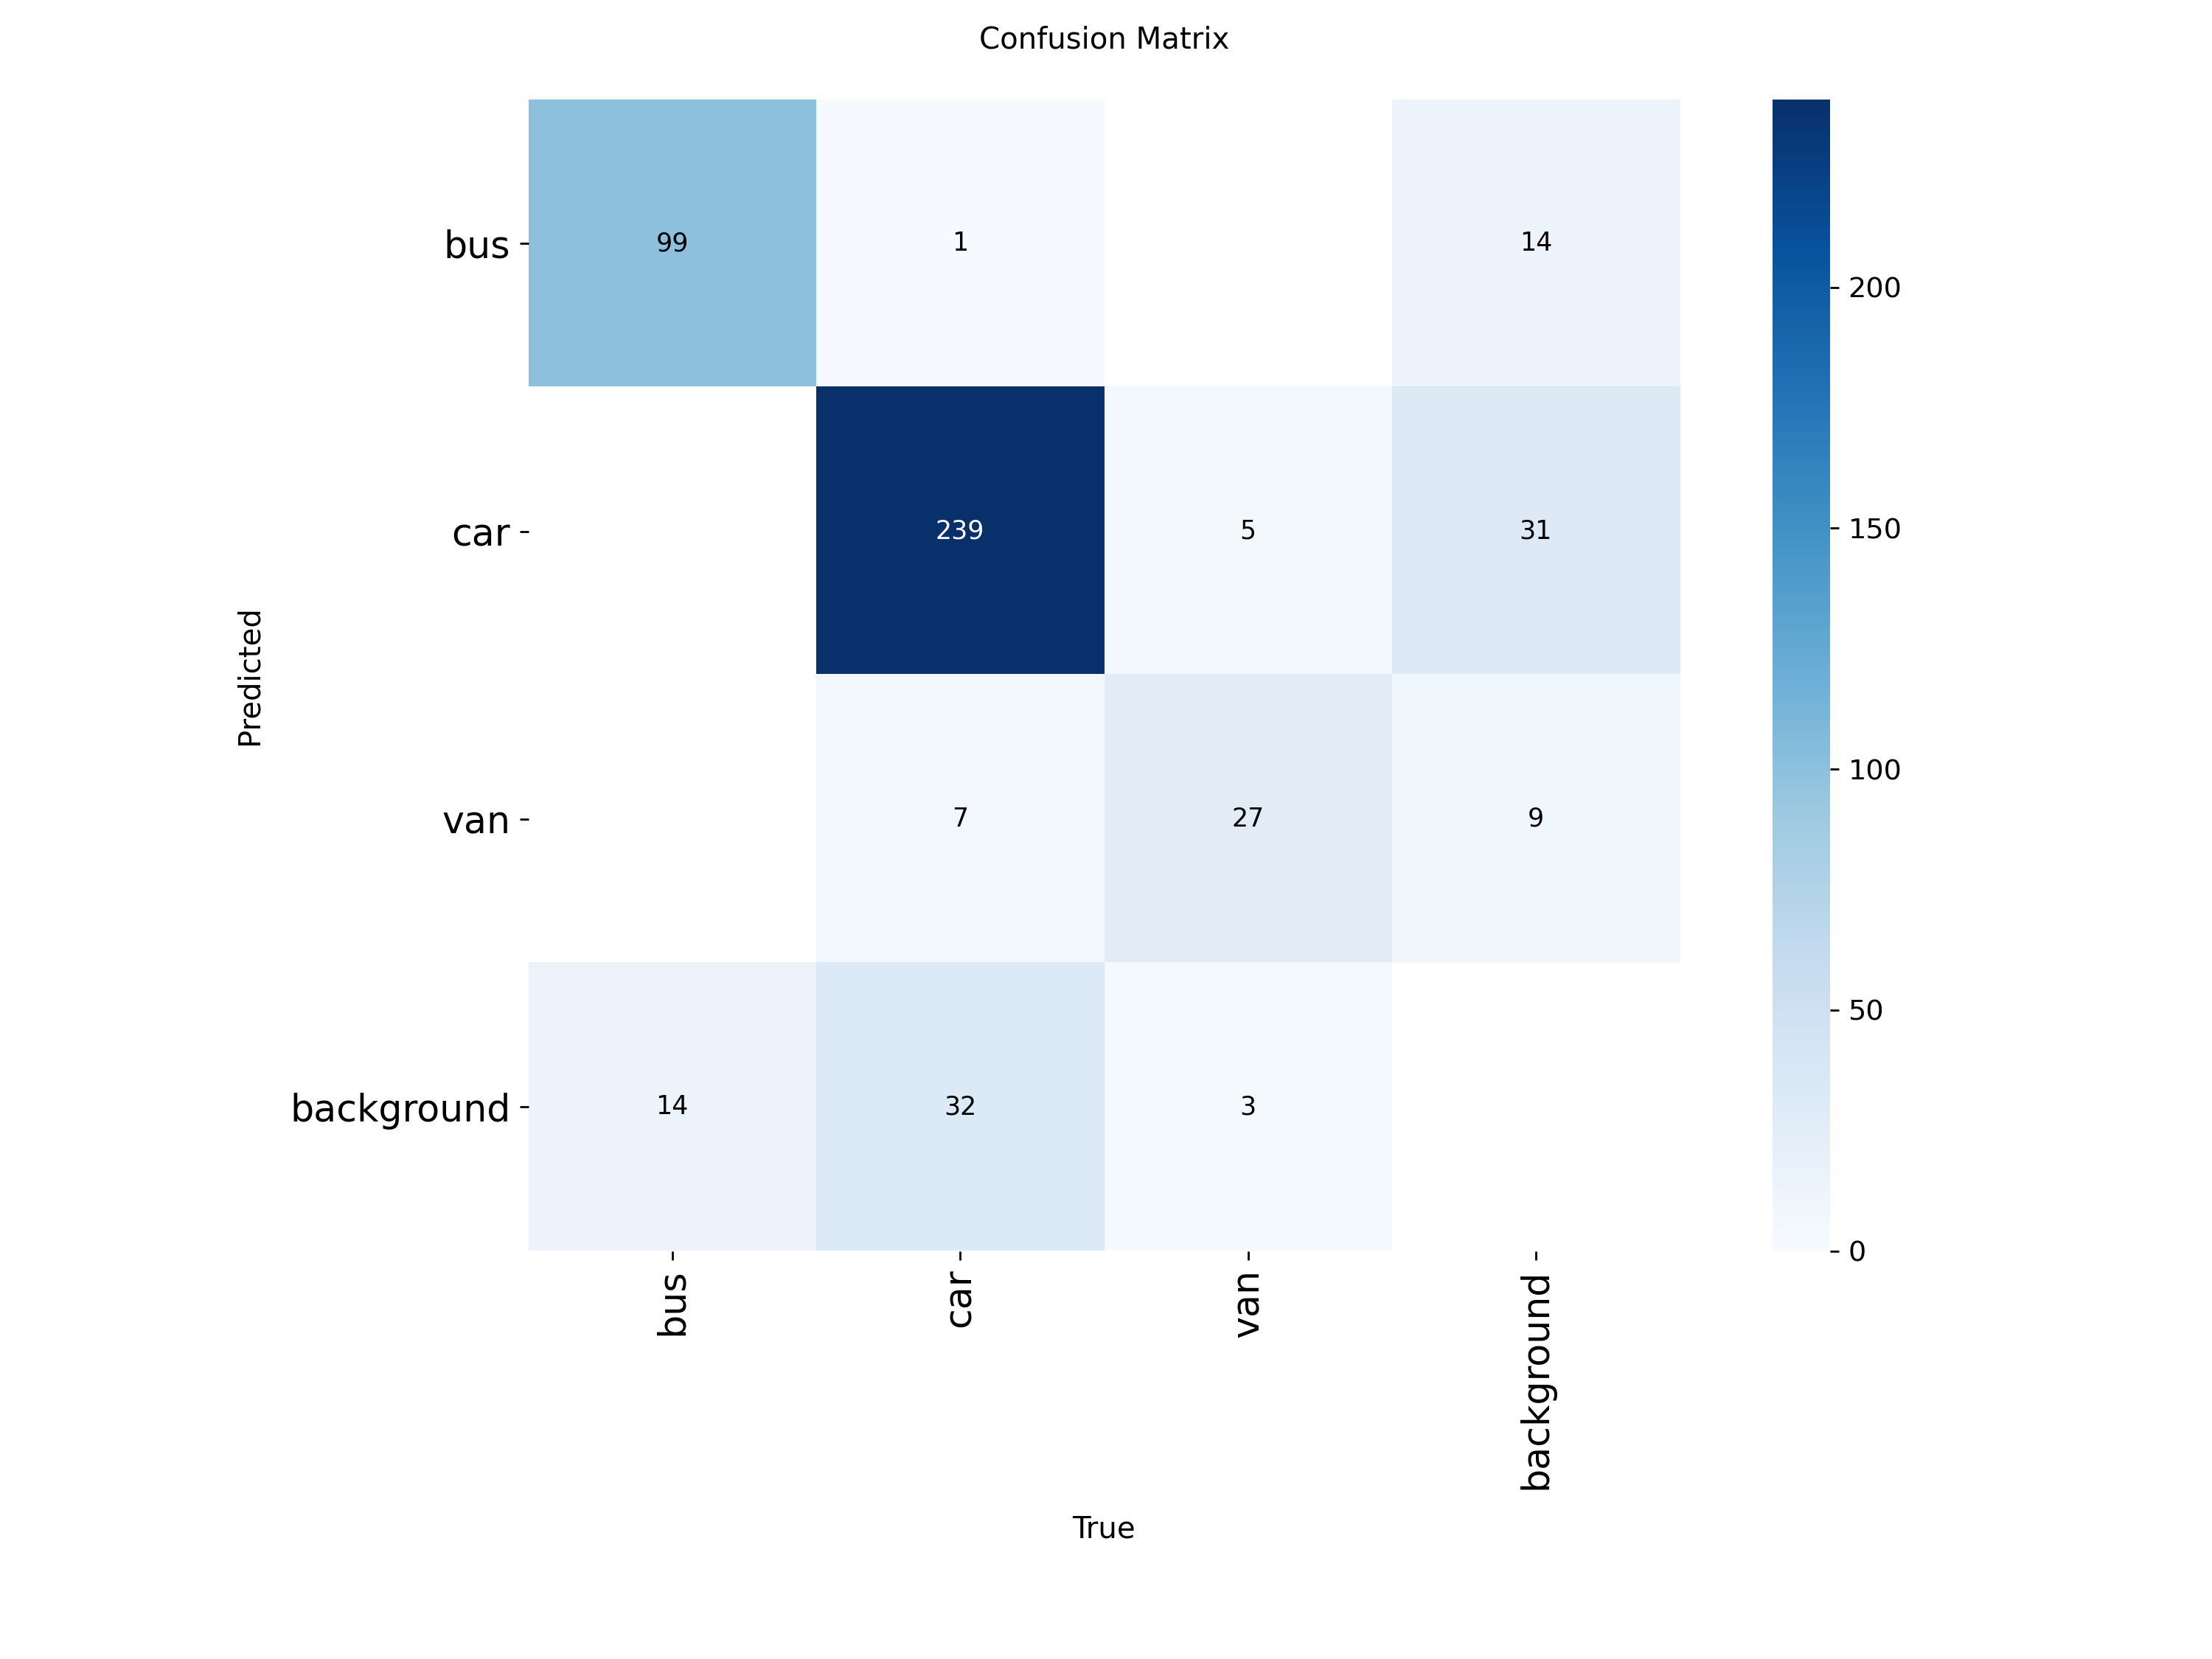

=== Training Metrics ===


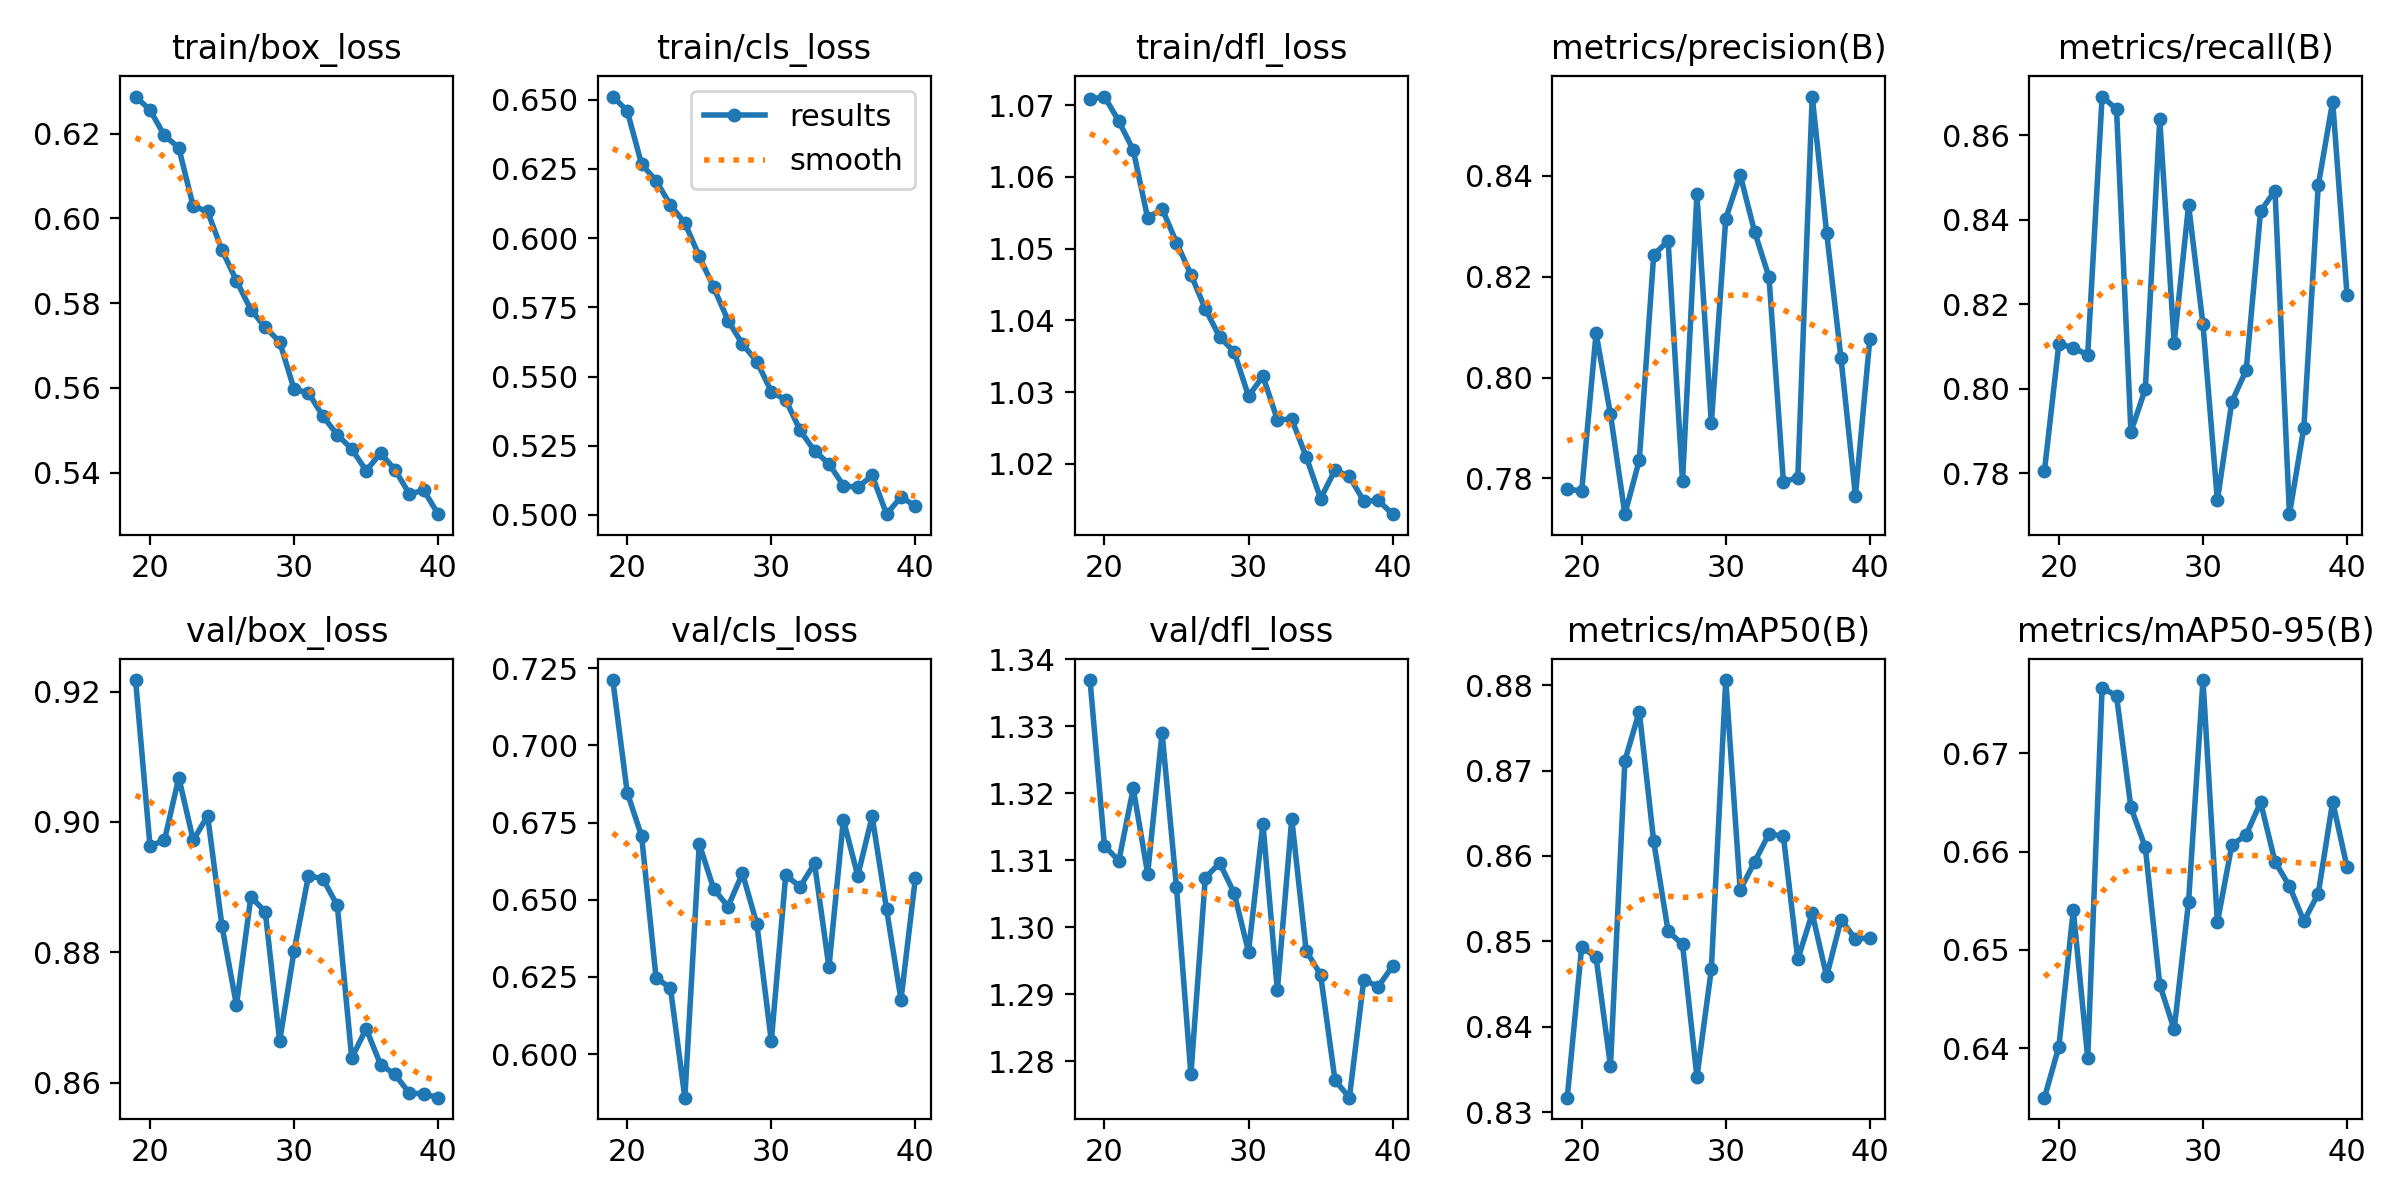

In [11]:
# Tampilkan hasil training (confusion matrix & metrics)
from IPython.display import Image, display

print("=== Confusion Matrix ===")
display(Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=700))

print("=== Training Metrics ===")
display(Image(filename=f'{HOME}/runs/detect/train/results.png', width=900))

In [12]:
# Evaluasi menggunakan best.pt pada test set
best_model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

# Validasi pada test set
test_results = best_model.val(
    data=f'{DATASET_PATH}/data.yaml',
    split='test',
    verbose=True
)

# Print ringkasan metrics
print("\n" + "="*50)
print("📊 RINGKASAN EVALUASI MODEL")
print("="*50)
print(f"mAP@0.5       : {test_results.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {test_results.box.map:.4f}")
print(f"Precision     : {test_results.box.mp:.4f}")
print(f"Recall        : {test_results.box.mr:.4f}")
print("="*50)

Ultralytics 8.4.52  Python-3.9.6 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050, 6144MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 21.410.2 MB/s, size: 47.1 KB)
val: Scanning C:\Users\User\Documents\CAPSTONE4\vehicle-detection\test\labels... 220 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 1.4Kit/s 0.2s<0.2s
val: New cache created: C:\Users\User\Documents\CAPSTONE4\vehicle-detection\test\labels.cache
WARNING Box and segment counts should be equal, but got len(segments) = 14, len(boxes) = 413. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.9it/s 2.9s0.2s
                   all        220        413      0.865      0.809      0.859      0.651

In [13]:
# Evaluasi per kelas menggunakan supervision
ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{DATASET_PATH}/test/images",
    annotations_directory_path=f"{DATASET_PATH}/test/labels",
    data_yaml_path=f"{DATASET_PATH}/data.yaml"
)

print(f"Test set classes: {ds.classes}")
print(f"Total test images: {len(ds)}")

Test set classes: ['bus', 'car', 'van']
Total test images: 220


In [14]:
# Hitung mAP menggunakan supervision
from supervision.metrics import MeanAveragePrecision

predictions = []
targets = []

for _, image, target in ds:
    result = best_model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    predictions.append(detections)
    targets.append(target)

map_result = MeanAveragePrecision().update(predictions, targets).compute()

print("\n" + "="*50)
print("📊 mAP HASIL SUPERVISION")
print("="*50)
print(f"mAP@50    : {map_result.map50:.4f}")
print(f"mAP@75    : {map_result.map75:.4f}")
print(f"mAP@50:95 : {map_result.map50_95:.4f}")
print("="*50)


📊 mAP HASIL SUPERVISION
mAP@50    : 0.8062
mAP@75    : 0.7144
mAP@50:95 : 0.6279


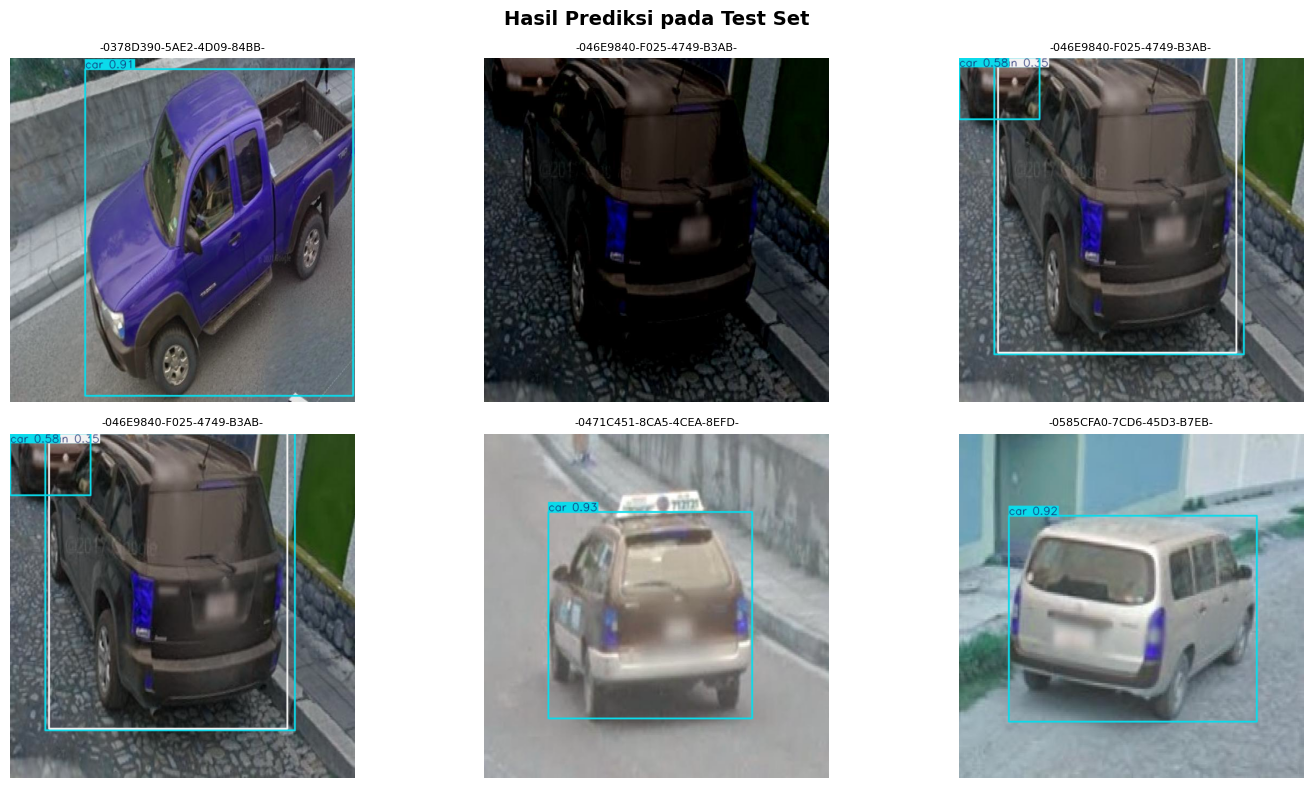

Visualisasi prediksi selesai! ✅


In [15]:
# Visualisasi prediksi pada beberapa gambar test
test_images = list(Path(f"{DATASET_PATH}/test/images").glob('*'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Hasil Prediksi pada Test Set', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, img_path in enumerate(test_images):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    result = best_model(img_rgb, verbose=False)[0]
    annotated = result.plot()  # YOLOv12 built-in visualizer
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[i].imshow(annotated_rgb)
    axes[i].set_title(img_path.stem[:25], fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi prediksi selesai! ✅")

## Step 6: Simpan Model ke Local Server

In [17]:
import shutil

SOURCE = r"runs\detect\train\weights\best.pt"
SAVE_PATH = r"best_vehicle.pt"

shutil.copy2(SOURCE, SAVE_PATH)

if os.path.exists(SAVE_PATH):
    size_mb = os.path.getsize(SAVE_PATH)/(1024*1024)

    print("✅ Model berhasil disimpan")
    print("Lokasi:", os.path.abspath(SAVE_PATH))
    print(f"Ukuran: {size_mb:.1f} MB")

else:
    print("❌ Gagal")

✅ Model berhasil disimpan
Lokasi: c:\Users\User\Documents\CAPSTONE4\best_vehicle.pt
Ukuran: 5.2 MB


In [18]:
# Simpan juga semua artifact training
# Folder tujuan lokal
ARTIFACT_PATH = r"training_artifacts"

os.makedirs(ARTIFACT_PATH, exist_ok=True)

FILES = [
    "label_distribution.png",
    "sample_data.png",
    "prediction_results.png",
    r"runs\detect\train\results.png",
    r"runs\detect\train\confusion_matrix.png",
    r"runs\detect\train\weights\best.pt"
]

for f in FILES:
    if os.path.exists(f):
        shutil.copy2(
            f,
            os.path.join(
                ARTIFACT_PATH,
                os.path.basename(f)
            )
        )
        print(f"✅ {f}")

    else:
        print(f"⚠️ Tidak ditemukan: {f}")

print("\nSelesai!")
print("Folder:", os.path.abspath(ARTIFACT_PATH))

✅ label_distribution.png
✅ sample_data.png
✅ prediction_results.png
✅ runs\detect\train\results.png
✅ runs\detect\train\confusion_matrix.png
✅ runs\detect\train\weights\best.pt

Selesai!
Folder: c:\Users\User\Documents\CAPSTONE4\training_artifacts
